In [1]:
# ============================================================
# STAGE 1: IMPORT LIBRARIES AND CHECK GPU
# ============================================================

import os
import gc
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

if tf.config.list_physical_devices("GPU"):
    print("GPU is ready.")
else:
    print("GPU was not detected.")

2026-07-20 23:06:38.950306: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-20 23:06:38.964126: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-20 23:06:38.968218: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-20 23:06:38.980974: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-20 23:06:39.735121: W tensorflow/compiler/tf2

TensorFlow version: 2.17.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is ready.


In [2]:
# ============================================================
# STAGE 2: PROJECT CONFIGURATION
# ============================================================

FILE_PATH = "portfolio_option1_EFA_VNQ_20years.csv"

REQUESTED_ASSETS = [
    "SPY",
    "QQQ",
    "AAPL",
    "MSFT",
    "NVDA",
    "TLT",
    "IEF",
    "VNQ",
    "EFA"
]

# LSTM input
SEQUENCE_LENGTH = 12
MIN_TRAIN_MONTHS = 60

# Model architecture
LSTM_UNITS = 16
DENSE_UNITS = 16
DROPOUT_RATE = 0.30
L2_RATE = 0.0001
LEARNING_RATE = 0.001

# Training settings
EPOCHS = 30
BATCH_SIZE = 32
PATIENCE = 5

# Portfolio threshold
PREDICTION_THRESHOLD = 0.60

# First test with one random seed
SEEDS = [42]

RISK_FREE_RATE = 0.00

print("File:", FILE_PATH)
print("Requested assets:", REQUESTED_ASSETS)
print("Seeds:", SEEDS)
print("Epochs:", EPOCHS)
print("Prediction threshold:", PREDICTION_THRESHOLD)

File: portfolio_option1_EFA_VNQ_20years.csv
Requested assets: ['SPY', 'QQQ', 'AAPL', 'MSFT', 'NVDA', 'TLT', 'IEF', 'VNQ', 'EFA']
Seeds: [42]
Epochs: 30
Prediction threshold: 0.6


In [3]:
# ============================================================
# STAGE 3: LOAD YFINANCE CSV
# ============================================================

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(
        f"Cannot find {FILE_PATH}. "
        "Make sure the CSV file is in the same folder as this notebook."
    )

raw_data = pd.read_csv(
    FILE_PATH,
    header=[0, 1],
    index_col=0,
    parse_dates=True
)

raw_data.index = pd.to_datetime(
    raw_data.index,
    errors="coerce"
)

raw_data = raw_data.loc[
    ~raw_data.index.isna()
].sort_index()

print("Raw data shape:", raw_data.shape)
print("Date range:", raw_data.index.min(), "to", raw_data.index.max())

print("\nPrice fields:")
print(
    raw_data.columns
    .get_level_values(0)
    .unique()
    .tolist()
)

print("\nTickers found:")
print(
    raw_data.columns
    .get_level_values(1)
    .unique()
    .tolist()
)

Raw data shape: (5153, 54)
Date range: 2006-01-03 00:00:00 to 2026-06-29 00:00:00

Price fields:
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Tickers found:
['AAPL', 'EFA', 'IEF', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TLT', 'VNQ']


In [4]:
# ============================================================
# STAGE 4: EXTRACT PRICE DATA AND CONVERT TO MONTHLY
# ============================================================

price_fields = (
    raw_data.columns
    .get_level_values(0)
    .unique()
    .tolist()
)

if "Adj Close" in price_fields:
    price_data = raw_data["Adj Close"].copy()
    price_field_used = "Adj Close"

elif "Close" in price_fields:
    price_data = raw_data["Close"].copy()
    price_field_used = "Close"

else:
    raise ValueError(
        "Cannot find 'Adj Close' or 'Close' in the CSV file."
    )

price_data = price_data.apply(
    pd.to_numeric,
    errors="coerce"
)

price_data = price_data.dropna(
    axis=1,
    how="all"
)

price_data = price_data.loc[
    :,
    ~price_data.columns.duplicated()
]

monthly_prices = price_data.resample("ME").last()

monthly_prices = monthly_prices.dropna(
    axis=0,
    how="all"
)

available_assets = [
    asset
    for asset in REQUESTED_ASSETS
    if asset in monthly_prices.columns
]

missing_assets = [
    asset
    for asset in REQUESTED_ASSETS
    if asset not in monthly_prices.columns
]

if len(available_assets) < 2:
    raise ValueError(
        "Fewer than two requested assets were found. "
        "Check the ticker names in the CSV."
    )

monthly_prices = monthly_prices[
    available_assets
].copy()

print("Price field used:", price_field_used)
print("Assets used:", available_assets)
print("Missing assets:", missing_assets)
print("Monthly data shape:", monthly_prices.shape)
print(
    "Monthly date range:",
    monthly_prices.index.min(),
    "to",
    monthly_prices.index.max()
)

display(monthly_prices.head())
display(monthly_prices.tail())

Price field used: Adj Close
Assets used: ['SPY', 'QQQ', 'AAPL', 'MSFT', 'NVDA', 'TLT', 'IEF', 'VNQ', 'EFA']
Missing assets: []
Monthly data shape: (246, 9)
Monthly date range: 2006-01-31 00:00:00 to 2026-06-30 00:00:00


Ticker,SPY,QQQ,AAPL,MSFT,NVDA,TLT,IEF,VNQ,EFA
Date,,,,,,,,,
2006-01-31,87.550270,35.862942,2.260425,19.541477,0.343089,47.280918,48.751446,27.222775,34.408585
2006-02-28,88.051537,35.094440,2.050277,18.716116,0.359648,47.804810,48.700985,27.728548,34.167732
2006-03-31,89.504730,35.828281,1.877549,18.952944,0.436950,45.620144,48.039654,29.035961,35.536201
2006-04-30,90.635361,35.759937,2.107155,16.821518,0.445954,44.364506,47.738392,28.048433,37.238564
2006-05-31,87.905327,33.170868,1.789241,15.838223,0.350720,44.279793,47.687382,27.291752,35.815361


Ticker,SPY,QQQ,AAPL,MSFT,NVDA,TLT,IEF,VNQ,EFA
Date,,,,,,,,,
2026-02-28,682.363708,605.859436,263.936829,391.891205,176.974152,89.475128,96.737495,93.850708,103.738388
2026-03-31,648.668884,576.546387,253.556381,369.369995,174.196976,85.690285,94.492989,87.925026,95.616905
2026-04-30,716.813293,667.006958,271.100250,406.898712,199.337677,84.970779,94.350937,95.488373,100.726059
2026-05-31,754.536133,737.499512,312.059998,450.239990,210.894211,85.424004,94.333000,94.863869,103.167435
2026-06-30,741.000000,724.080017,281.739990,368.570007,194.970001,87.449997,95.059998,98.150002,103.449997


In [5]:
# ============================================================
# STAGE 5: FEATURE ENGINEERING
# ============================================================

FEATURE_COLUMNS = [
    "return_1m",
    "return_3m",
    "return_6m",
    "volatility_3m",
    "volatility_6m",
    "trend_signal"
]


def create_asset_dataset(price_series):
    """
    Create monthly features for one asset.

    Features at month t are used to predict whether
    the return from month t to month t+1 is positive.
    """

    df = pd.DataFrame(index=price_series.index)

    df["price"] = price_series

    monthly_return = price_series.pct_change()

    # Momentum features
    df["return_1m"] = monthly_return
    df["return_3m"] = price_series.pct_change(3)
    df["return_6m"] = price_series.pct_change(6)

    # Volatility features
    df["volatility_3m"] = monthly_return.rolling(3).std()
    df["volatility_6m"] = monthly_return.rolling(6).std()

    # Trend feature
    moving_average_3m = price_series.rolling(3).mean()
    moving_average_6m = price_series.rolling(6).mean()

    df["trend_signal"] = (
        moving_average_3m / moving_average_6m
    ) - 1

    # Next-month realized return
    df["actual_return"] = monthly_return.shift(-1)

    # Classification target:
    # 1 = next-month return is positive
    # 0 = next-month return is zero or negative
    df["target"] = (
        df["actual_return"] > 0
    ).astype(int)

    df = df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    df = df.dropna()

    return df


asset_datasets = {}

for asset in available_assets:
    asset_dataset = create_asset_dataset(
        monthly_prices[asset]
    )

    asset_datasets[asset] = asset_dataset

    print(
        f"{asset}: "
        f"{len(asset_dataset)} observations | "
        f"Positive rate: {asset_dataset['target'].mean():.2%}"
    )

first_asset = available_assets[0]

print("\nExample dataset:", first_asset)
display(asset_datasets[first_asset].head())

print("\nFeature columns:")
print(FEATURE_COLUMNS)

SPY: 239 observations | Positive rate: 66.53%
QQQ: 239 observations | Positive rate: 63.60%
AAPL: 239 observations | Positive rate: 60.67%
MSFT: 239 observations | Positive rate: 59.83%
NVDA: 239 observations | Positive rate: 63.18%
TLT: 239 observations | Positive rate: 51.88%
IEF: 239 observations | Positive rate: 53.97%
VNQ: 239 observations | Positive rate: 59.00%
EFA: 239 observations | Positive rate: 59.83%

Example dataset: SPY


,price,return_1m,return_3m,return_6m,volatility_3m,volatility_6m,trend_signal,actual_return,target
Date,,,,,,,,,
2006-07-31,88.529297,0.004478,-0.023237,0.011182,0.019459,0.016586,-0.006799,0.021822,1
2006-08-31,90.461205,0.021822,0.029075,0.027367,0.010595,0.018506,-0.001720,0.027002,1
2006-09-30,92.903816,0.027002,0.054113,0.037977,0.011796,0.020263,0.009691,0.031517,1
2006-10-31,95.831825,0.031517,0.082487,0.057334,0.004851,0.022739,0.026901,0.019885,1
2006-11-30,97.737465,0.019885,0.080435,0.111849,0.005864,0.011845,0.034950,0.013371,1



Feature columns:
['return_1m', 'return_3m', 'return_6m', 'volatility_3m', 'volatility_6m', 'trend_signal']


In [6]:
# ============================================================
# STAGE 6: CREATE SEQUENCES AND BUILD LSTM MODEL
# ============================================================

def create_training_sequences(
    scaled_features,
    targets,
    sequence_length
):
    """
    Convert monthly feature rows into LSTM sequences.

    Example:
    12 months of features -> predict direction for the last
    month in that sequence.
    """

    X_sequences = []
    y_sequences = []

    for end_index in range(
        sequence_length - 1,
        len(scaled_features)
    ):
        start_index = end_index - sequence_length + 1

        X_sequences.append(
            scaled_features[
                start_index:end_index + 1
            ]
        )

        y_sequences.append(
            targets[end_index]
        )

    X_sequences = np.asarray(
        X_sequences,
        dtype=np.float32
    )

    y_sequences = np.asarray(
        y_sequences,
        dtype=np.float32
    )

    return X_sequences, y_sequences


def build_lstm_model(
    sequence_length,
    number_of_features
):
    """
    Build and compile one LSTM classification model.
    """

    model = Sequential([
        Input(
            shape=(
                sequence_length,
                number_of_features
            )
        ),

        LSTM(
            units=LSTM_UNITS,
            kernel_regularizer=l2(L2_RATE),
            recurrent_regularizer=l2(L2_RATE)
        ),

        Dropout(DROPOUT_RATE),

        Dense(
            units=DENSE_UNITS,
            activation="relu",
            kernel_regularizer=l2(L2_RATE)
        ),

        Dropout(DROPOUT_RATE),

        Dense(
            units=1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Quick test to make sure the model can be created
test_model = build_lstm_model(
    sequence_length=SEQUENCE_LENGTH,
    number_of_features=len(FEATURE_COLUMNS)
)

test_model.summary()

del test_model
tf.keras.backend.clear_session()

print("\nSequence function and LSTM model are ready.")

2026-07-20 23:07:03.633125: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22325 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:81:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,761 (6.88 KB)

 Trainable params: 1,761 (6.88 KB)

 Non-trainable params: 0 (0.00 B)


Sequence function and LSTM model are ready.


In [7]:
# ============================================================
# STAGE 7: WALK-FORWARD VALIDATION FOR ONE ASSET
# ============================================================

def set_random_seed(seed):
    """
    Make the experiment more reproducible.
    """
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def run_asset_walk_forward(
    asset_name,
    asset_df,
    seed
):
    """
    Expanding-window walk-forward validation.

    For each test month:
    1. Train only on earlier months.
    2. Fit StandardScaler only on training data.
    3. Train a new LSTM model.
    4. Predict the next-month direction.
    """

    set_random_seed(seed)

    results = []

    first_test_index = max(
        MIN_TRAIN_MONTHS,
        SEQUENCE_LENGTH
    )

    total_test_months = (
        len(asset_df) - first_test_index
    )

    if total_test_months <= 0:
        print(
            f"Skipping {asset_name}: "
            "not enough observations."
        )
        return pd.DataFrame()

    for counter, test_index in enumerate(
        range(
            first_test_index,
            len(asset_df)
        ),
        start=1
    ):
        # Training data only includes months before test month
        train_df = asset_df.iloc[
            :test_index
        ].copy()

        scaler = StandardScaler()

        train_features_raw = train_df[
            FEATURE_COLUMNS
        ].values

        train_features_scaled = scaler.fit_transform(
            train_features_raw
        )

        train_targets = train_df[
            "target"
        ].values

        X_train, y_train = create_training_sequences(
            scaled_features=train_features_scaled,
            targets=train_targets,
            sequence_length=SEQUENCE_LENGTH
        )

        # Build the 12-month sequence for current test month
        test_sequence_raw = asset_df[
            FEATURE_COLUMNS
        ].iloc[
            test_index - SEQUENCE_LENGTH + 1:
            test_index + 1
        ].values

        test_sequence_scaled = scaler.transform(
            test_sequence_raw
        )

        X_test = test_sequence_scaled.reshape(
            1,
            SEQUENCE_LENGTH,
            len(FEATURE_COLUMNS)
        ).astype(np.float32)

        # Clear old model from memory
        tf.keras.backend.clear_session()
        gc.collect()

        set_random_seed(seed)

        model = build_lstm_model(
            sequence_length=SEQUENCE_LENGTH,
            number_of_features=len(FEATURE_COLUMNS)
        )

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=0
        )

        model.fit(
            X_train,
            y_train,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.20,
            shuffle=False,
            callbacks=[early_stopping],
            verbose=0
        )

        probability = float(
            model.predict(
                X_test,
                verbose=0
            )[0, 0]
        )

        prediction = int(
            probability >= PREDICTION_THRESHOLD
        )

        test_row = asset_df.iloc[test_index]

        results.append({
            "asset": asset_name,
            "signal_date": asset_df.index[test_index],
            "probability": probability,
            "prediction": prediction,
            "actual_direction": int(
                test_row["target"]
            ),
            "actual_return": float(
                test_row["actual_return"]
            ),
            "seed": seed
        })

        if (
            counter == 1
            or counter % 12 == 0
            or counter == total_test_months
        ):
            print(
                f"Seed {seed} | "
                f"{asset_name} | "
                f"{counter}/{total_test_months}"
            )

        del model
        del X_train
        del y_train
        del X_test

        gc.collect()

    return pd.DataFrame(results)


print("Walk-forward validation function is ready.")

Walk-forward validation function is ready.


In [8]:
# ============================================================
# STAGE 8: BUILD LSTM PORTFOLIO
# ============================================================

def build_lstm_portfolio(prediction_results):
    """
    Create an equal-weight portfolio from assets that the
    LSTM predicts will have a positive next-month return.

    If no asset is selected in a month, the portfolio stays
    in cash and earns 0% for that month.
    """

    portfolio_records = []

    for signal_date, month_df in prediction_results.groupby(
        "signal_date"
    ):
        selected_rows = month_df.loc[
            month_df["prediction"] == 1
        ].copy()

        selected_assets = selected_rows[
            "asset"
        ].tolist()

        if len(selected_rows) > 0:
            portfolio_return = selected_rows[
                "actual_return"
            ].mean()
        else:
            portfolio_return = 0.0

        portfolio_records.append({
            "date": signal_date,
            "lstm_return": float(portfolio_return),
            "number_selected": len(selected_assets),
            "selected_assets": ", ".join(selected_assets)
        })

    portfolio_df = pd.DataFrame(
        portfolio_records
    )

    portfolio_df["date"] = pd.to_datetime(
        portfolio_df["date"]
    )

    portfolio_df = portfolio_df.set_index(
        "date"
    ).sort_index()

    return portfolio_df


print("LSTM portfolio function is ready.")

LSTM portfolio function is ready.


In [9]:
# ============================================================
# STAGE 9: PERFORMANCE METRICS
# ============================================================

def calculate_performance_metrics(
    return_series,
    risk_free_rate=0.0
):
    """
    Calculate portfolio performance metrics from monthly returns.
    """

    returns = pd.Series(return_series).dropna()

    if len(returns) == 0:
        return {
            "Cumulative Return": np.nan,
            "CAGR": np.nan,
            "Annual Volatility": np.nan,
            "Sharpe Ratio": np.nan,
            "Maximum Drawdown": np.nan
        }

    wealth = (1 + returns).cumprod()

    cumulative_return = wealth.iloc[-1] - 1

    years = len(returns) / 12

    if years > 0 and wealth.iloc[-1] > 0:
        cagr = wealth.iloc[-1] ** (1 / years) - 1
    else:
        cagr = np.nan

    annual_volatility = returns.std() * np.sqrt(12)

    annualized_average_return = returns.mean() * 12

    if annual_volatility > 0:
        sharpe_ratio = (
            annualized_average_return - risk_free_rate
        ) / annual_volatility
    else:
        sharpe_ratio = np.nan

    running_peak = wealth.cummax()

    drawdown = wealth / running_peak - 1

    maximum_drawdown = drawdown.min()

    return {
        "Cumulative Return": cumulative_return,
        "CAGR": cagr,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown
    }


print("Performance metric function is ready.")

Performance metric function is ready.


In [10]:
# ============================================================
# STAGE 10: TEST WALK-FORWARD ON ONE ASSET
# ============================================================

TEST_ASSET = "SPY"
TEST_SEED = 42

print("Testing asset:", TEST_ASSET)
print("Seed:", TEST_SEED)

test_predictions = run_asset_walk_forward(
    asset_name=TEST_ASSET,
    asset_df=asset_datasets[TEST_ASSET],
    seed=TEST_SEED
)

print("\nTest completed.")
print("Prediction shape:", test_predictions.shape)

display(test_predictions.head())
display(test_predictions.tail())

Testing asset: SPY
Seed: 42


2026-07-20 23:07:18.424542: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


Seed 42 | SPY | 1/179
Seed 42 | SPY | 12/179
Seed 42 | SPY | 24/179
Seed 42 | SPY | 36/179
Seed 42 | SPY | 48/179
Seed 42 | SPY | 60/179
Seed 42 | SPY | 72/179
Seed 42 | SPY | 84/179
Seed 42 | SPY | 96/179
Seed 42 | SPY | 108/179
Seed 42 | SPY | 120/179
Seed 42 | SPY | 132/179
Seed 42 | SPY | 144/179
Seed 42 | SPY | 156/179
Seed 42 | SPY | 168/179
Seed 42 | SPY | 179/179

Test completed.
Prediction shape: (179, 7)


,asset,signal_date,probability,prediction,actual_direction,actual_return,seed
0,SPY,2011-07-31,0.528073,0,0,-0.054976,42
1,SPY,2011-08-31,0.513758,0,0,-0.069421,42
2,SPY,2011-09-30,0.505268,0,1,0.109147,42
3,SPY,2011-10-31,0.515587,0,0,-0.004064,42
4,SPY,2011-11-30,0.524039,0,1,0.010449,42


,asset,signal_date,probability,prediction,actual_direction,actual_return,seed
174,SPY,2026-01-31,0.651109,1,0,-0.008642,42
175,SPY,2026-02-28,0.644660,1,0,-0.049380,42
176,SPY,2026-03-31,0.644055,1,1,0.105053,42
177,SPY,2026-04-30,0.621957,1,1,0.052626,42
178,SPY,2026-05-31,0.645389,1,0,-0.017940,42


In [11]:
# ============================================================
# STAGE 11 NEW: RUN WITH AUTOMATIC CHECKPOINTS
# ============================================================

CHECKPOINT_FILE = "lstm_predictions_checkpoint.csv"
RUN_SEED = 42

# Clear anything left from the interrupted model
tf.keras.backend.clear_session()
gc.collect()

# ------------------------------------------------------------
# 1. Load an existing checkpoint if one already exists
# ------------------------------------------------------------

if os.path.exists(CHECKPOINT_FILE):
    checkpoint_df = pd.read_csv(
        CHECKPOINT_FILE,
        parse_dates=["signal_date"]
    )

    print("Existing checkpoint loaded.")
    print("Checkpoint rows:", len(checkpoint_df))

# If there is no checkpoint yet, reuse the completed SPY test
elif (
    "test_predictions" in globals()
    and isinstance(test_predictions, pd.DataFrame)
    and not test_predictions.empty
):
    checkpoint_df = test_predictions.copy()

    checkpoint_df.to_csv(
        CHECKPOINT_FILE,
        index=False
    )

    print("The completed SPY test was saved as the first checkpoint.")

else:
    checkpoint_df = pd.DataFrame(
        columns=[
            "asset",
            "signal_date",
            "probability",
            "prediction",
            "actual_direction",
            "actual_return",
            "seed"
        ]
    )

    print("Starting with an empty checkpoint.")


# ------------------------------------------------------------
# 2. Determine whether each asset is fully completed
# ------------------------------------------------------------

completed_assets = []

for asset in available_assets:
    expected_rows = (
        len(asset_datasets[asset])
        - max(MIN_TRAIN_MONTHS, SEQUENCE_LENGTH)
    )

    saved_rows = len(
        checkpoint_df.loc[
            checkpoint_df["asset"] == asset
        ]
    )

    if saved_rows == expected_rows:
        completed_assets.append(asset)

    print(
        f"{asset}: saved {saved_rows}/{expected_rows}"
    )

remaining_assets = [
    asset
    for asset in available_assets
    if asset not in completed_assets
]

print("\nCompleted assets:", completed_assets)
print("Remaining assets:", remaining_assets)


# ------------------------------------------------------------
# 3. Run only unfinished assets
# ------------------------------------------------------------

for asset in remaining_assets:
    print("\n" + "=" * 70, flush=True)
    print(f"RUNNING ASSET: {asset}", flush=True)
    print("=" * 70, flush=True)

    # Remove incomplete rows for this asset, if any
    checkpoint_df = checkpoint_df.loc[
        checkpoint_df["asset"] != asset
    ].copy()

    asset_result = run_asset_walk_forward(
        asset_name=asset,
        asset_df=asset_datasets[asset],
        seed=RUN_SEED
    )

    if asset_result.empty:
        print(
            f"No predictions produced for {asset}.",
            flush=True
        )
        continue

    checkpoint_df = pd.concat(
        [checkpoint_df, asset_result],
        ignore_index=True
    )

    checkpoint_df = checkpoint_df.sort_values(
        ["asset", "signal_date"]
    ).reset_index(drop=True)

    checkpoint_df.to_csv(
        CHECKPOINT_FILE,
        index=False
    )

    print(
        f"\nCheckpoint saved after completing {asset}.",
        flush=True
    )

    print(
        f"Total saved rows: {len(checkpoint_df)}",
        flush=True
    )

    tf.keras.backend.clear_session()
    gc.collect()


# ------------------------------------------------------------
# 4. Final combined predictions
# ------------------------------------------------------------

predictions_df = checkpoint_df.copy()

print("\n" + "=" * 70)
print("CHECKPOINT RUN COMPLETED")
print("=" * 70)

print("Prediction shape:", predictions_df.shape)

print(
    "Assets saved:",
    predictions_df["asset"].unique().tolist()
)

display(predictions_df.head())
display(predictions_df.tail())

Existing checkpoint loaded.
Checkpoint rows: 358
SPY: saved 179/179
QQQ: saved 179/179
AAPL: saved 0/179
MSFT: saved 0/179
NVDA: saved 0/179
TLT: saved 0/179
IEF: saved 0/179
VNQ: saved 0/179
EFA: saved 0/179

Completed assets: ['SPY', 'QQQ']
Remaining assets: ['AAPL', 'MSFT', 'NVDA', 'TLT', 'IEF', 'VNQ', 'EFA']

RUNNING ASSET: AAPL
Seed 42 | AAPL | 1/179
Seed 42 | AAPL | 12/179
Seed 42 | AAPL | 24/179
Seed 42 | AAPL | 36/179
Seed 42 | AAPL | 48/179
Seed 42 | AAPL | 60/179
Seed 42 | AAPL | 72/179
Seed 42 | AAPL | 84/179
Seed 42 | AAPL | 96/179
Seed 42 | AAPL | 108/179
Seed 42 | AAPL | 120/179
Seed 42 | AAPL | 132/179
Seed 42 | AAPL | 144/179
Seed 42 | AAPL | 156/179
Seed 42 | AAPL | 168/179
Seed 42 | AAPL | 179/179

Checkpoint saved after completing AAPL.
Total saved rows: 537

RUNNING ASSET: MSFT
Seed 42 | MSFT | 1/179
Seed 42 | MSFT | 12/179
Seed 42 | MSFT | 24/179
Seed 42 | MSFT | 36/179
Seed 42 | MSFT | 48/179
Seed 42 | MSFT | 60/179
Seed 42 | MSFT | 72/179
Seed 42 | MSFT | 84/179


,asset,signal_date,probability,prediction,actual_direction,actual_return,seed
0,AAPL,2011-07-31,0.648176,1,0,-0.014469,42
1,AAPL,2011-08-31,0.578038,0,0,-0.009121,42
2,AAPL,2011-09-30,0.562183,0,1,0.061523,42
3,AAPL,2011-10-31,0.561219,0,0,-0.055783,42
4,AAPL,2011-11-30,0.561495,0,1,0.059655,42


,asset,signal_date,probability,prediction,actual_direction,actual_return,seed
1606,VNQ,2026-01-31,0.591705,0,1,0.053855,42
1607,VNQ,2026-02-28,0.577295,0,0,-0.063139,42
1608,VNQ,2026-03-31,0.590797,0,1,0.086020,42
1609,VNQ,2026-04-30,0.558109,0,0,-0.006540,42
1610,VNQ,2026-05-31,0.553558,0,1,0.034641,42


In [12]:
# ============================================================
# STAGE 12: BUILD PORTFOLIO AND CLASSIFICATION METRICS
# ============================================================

# Use the completed checkpoint results
predictions_df = pd.read_csv(
    "lstm_predictions_checkpoint.csv",
    parse_dates=["signal_date"]
)

print("Prediction rows:", len(predictions_df))
print("Assets:", predictions_df["asset"].unique().tolist())

# Build monthly LSTM portfolio
lstm_portfolio = build_lstm_portfolio(
    predictions_df
)

print("\nLSTM portfolio shape:", lstm_portfolio.shape)
display(lstm_portfolio.head())
display(lstm_portfolio.tail())

# Classification metrics
y_true = predictions_df["actual_direction"]
y_pred = predictions_df["prediction"]

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1]
)

print("\nClassification Metrics")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

print("\nConfusion Matrix")
print(cm)

Prediction rows: 1611
Assets: ['AAPL', 'EFA', 'IEF', 'MSFT', 'NVDA', 'QQQ', 'SPY', 'TLT', 'VNQ']

LSTM portfolio shape: (179, 3)


,lstm_return,number_selected,selected_assets
date,,,
2011-07-31,0.041102,2,"AAPL, TLT"
2011-08-31,0.022370,1,IEF
2011-09-30,0.183053,1,NVDA
2011-10-31,0.056081,1,NVDA
2011-11-30,-0.113244,1,NVDA


,lstm_return,number_selected,selected_assets
date,,,
2026-01-31,-0.008642,1,SPY
2026-02-28,-0.049380,1,SPY
2026-03-31,0.130977,2,"QQQ, SPY"
2026-04-30,0.072095,3,"NVDA, QQQ, SPY"
2026-05-31,-0.037215,3,"NVDA, QQQ, SPY"



Classification Metrics
Accuracy: 0.4358
Precision: 0.5951
Recall: 0.1998
F1 Score: 0.2992

Confusion Matrix
[[508 132]
 [777 194]]


In [13]:
# ============================================================
# STAGE 13: CREATE BENCHMARKS AND COMPARE PERFORMANCE
# ============================================================

# Monthly returns for all available assets
monthly_returns = monthly_prices.pct_change()

# Equal Weight benchmark
equal_weight_return = monthly_returns[
    available_assets
].mean(axis=1)

benchmark_returns = pd.DataFrame({
    "Equal Weight": equal_weight_return
})

# SPY benchmark
if "SPY" in monthly_returns.columns:
    benchmark_returns["SPY"] = monthly_returns["SPY"]

# 60/40 benchmark
if (
    "SPY" in monthly_returns.columns
    and "TLT" in monthly_returns.columns
):
    benchmark_returns["60/40"] = (
        0.60 * monthly_returns["SPY"]
        + 0.40 * monthly_returns["TLT"]
    )

    print("60/40 benchmark uses SPY and TLT.")

elif (
    "SPY" in monthly_returns.columns
    and "IEF" in monthly_returns.columns
):
    benchmark_returns["60/40"] = (
        0.60 * monthly_returns["SPY"]
        + 0.40 * monthly_returns["IEF"]
    )

    print("60/40 benchmark uses SPY and IEF.")

else:
    print("60/40 benchmark could not be created.")

# Add LSTM portfolio returns
comparison_returns = benchmark_returns.copy()

comparison_returns["LSTM"] = lstm_portfolio[
    "lstm_return"
]

# Keep only months available for every strategy
comparison_returns = comparison_returns.dropna()

# Put LSTM first
column_order = ["LSTM"] + [
    column
    for column in comparison_returns.columns
    if column != "LSTM"
]

comparison_returns = comparison_returns[
    column_order
]

print("\nComparison period:")
print(
    comparison_returns.index.min(),
    "to",
    comparison_returns.index.max()
)

print("Number of test months:", len(comparison_returns))

display(comparison_returns.head())
display(comparison_returns.tail())

# Calculate performance table
performance_results = {}

for strategy in comparison_returns.columns:
    performance_results[strategy] = (
        calculate_performance_metrics(
            comparison_returns[strategy],
            risk_free_rate=RISK_FREE_RATE
        )
    )

performance_table = pd.DataFrame(
    performance_results
).T

performance_table = performance_table[
    [
        "Cumulative Return",
        "CAGR",
        "Annual Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ]
]

print("\nFinal Performance Comparison")

display(
    performance_table.style.format({
        "Cumulative Return": "{:.2%}",
        "CAGR": "{:.2%}",
        "Annual Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}"
    })
)

60/40 benchmark uses SPY and TLT.

Comparison period:
2011-07-31 00:00:00 to 2026-05-31 00:00:00
Number of test months: 179


,LSTM,Equal Weight,SPY,60/40
Date,,,,
2011-07-31,0.041102,0.016568,-0.020005,0.005656
2011-08-31,0.022370,-0.020151,-0.054976,0.005684
2011-09-30,0.183053,-0.034435,-0.069421,0.011173
2011-10-31,0.056081,0.079520,0.109147,0.050171
2011-11-30,-0.113244,-0.010774,-0.004064,0.005518


,LSTM,Equal Weight,SPY,60/40
Date,,,,
2026-01-31,-0.008642,-0.003491,0.014738,0.008705
2026-02-28,-0.049380,-0.000021,-0.008642,0.013350
2026-03-31,0.130977,-0.046354,-0.049380,-0.046548
2026-04-30,0.072095,0.078514,0.105053,0.059673
2026-05-31,-0.037215,0.055192,0.052626,0.033709



Final Performance Comparison


,Cumulative Return,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown
LSTM,318.22%,10.07%,18.92%,0.602,-41.55%
Equal Weight,1067.50%,17.91%,13.94%,1.259,-30.23%
SPY,644.42%,14.41%,14.35%,1.014,-23.93%
60/40,307.80%,9.88%,10.08%,0.989,-26.21%


In [16]:
# ============================================================
# STAGE 13B: WALK-FORWARD MEAN-VARIANCE OPTIMIZATION
# ============================================================

from scipy.optimize import minimize

# Use the same test dates as the LSTM portfolio
test_dates = comparison_returns.index

# Use monthly returns from the assets in the portfolio
asset_monthly_returns = monthly_prices[
    available_assets
].pct_change()


def calculate_mvo_weights(
    historical_returns,
    risk_free_rate=0.0
):
    """
    Find long-only portfolio weights that maximize
    the historical annualized Sharpe ratio.

    Constraints:
    - Weights sum to 1
    - No short selling
    """

    historical_returns = historical_returns.dropna(
        axis=0,
        how="any"
    )

    number_of_assets = historical_returns.shape[1]

    if len(historical_returns) < 12:
        return np.repeat(
            1 / number_of_assets,
            number_of_assets
        )

    expected_annual_returns = (
        historical_returns.mean() * 12
    ).values

    annual_covariance = (
        historical_returns.cov() * 12
    ).values

    def negative_sharpe(weights):
        portfolio_return = np.dot(
            weights,
            expected_annual_returns
        )

        portfolio_variance = np.dot(
            weights,
            np.dot(annual_covariance, weights)
        )

        portfolio_volatility = np.sqrt(
            max(portfolio_variance, 0)
        )

        if portfolio_volatility == 0:
            return 1e6

        sharpe_ratio = (
            portfolio_return - risk_free_rate
        ) / portfolio_volatility

        return -sharpe_ratio

    initial_weights = np.repeat(
        1 / number_of_assets,
        number_of_assets
    )

    bounds = [
        (0.0, 1.0)
        for _ in range(number_of_assets)
    ]

    constraints = {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }

    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={
            "maxiter": 1000,
            "ftol": 1e-9
        }
    )

    if not result.success:
        return initial_weights

    return result.x


mvo_records = []

for test_date in test_dates:

    # Only data known before the portfolio return month
    historical_returns = asset_monthly_returns.loc[
        asset_monthly_returns.index < test_date
    ].copy()

    # Current-month realized returns
    current_returns = asset_monthly_returns.loc[
        test_date,
        available_assets
    ]

    weights = calculate_mvo_weights(
        historical_returns=historical_returns,
        risk_free_rate=RISK_FREE_RATE
    )

    mvo_return = np.dot(
        weights,
        current_returns.values
    )

    record = {
        "date": test_date,
        "MVO_return": float(mvo_return)
    }

    for asset, weight in zip(
        available_assets,
        weights
    ):
        record[f"weight_{asset}"] = weight

    mvo_records.append(record)


mvo_results = pd.DataFrame(
    mvo_records
).set_index("date")

print("MVO results shape:", mvo_results.shape)

display(mvo_results.head())
display(mvo_results.tail())

MVO results shape: (179, 10)


,MVO_return,weight_SPY,weight_QQQ,weight_AAPL,weight_MSFT,weight_NVDA,weight_TLT,weight_IEF,weight_VNQ,weight_EFA
date,,,,,,,,,,
2011-07-31,0.050364,0.000000e+00,0.000000e+00,0.150092,0.000000e+00,0.006596,0.000000e+00,0.843312,4.624881e-16,0.000000e+00
2011-08-31,0.036822,8.721106e-17,0.000000e+00,0.150492,5.301997e-16,0.006121,0.000000e+00,0.843387,0.000000e+00,1.380262e-16
2011-09-30,0.017220,0.000000e+00,6.238210e-16,0.146915,3.678028e-16,0.006347,2.614728e-15,0.846739,0.000000e+00,4.715473e-16
2011-10-31,-0.001037,0.000000e+00,0.000000e+00,0.144201,9.490505e-16,0.005621,4.069267e-16,0.850178,0.000000e+00,0.000000e+00
2011-11-30,-0.002649,7.993112e-17,7.861449e-16,0.145598,4.588887e-16,0.010297,4.707208e-17,0.844106,0.000000e+00,0.000000e+00


,MVO_return,weight_SPY,weight_QQQ,weight_AAPL,weight_MSFT,weight_NVDA,weight_TLT,weight_IEF,weight_VNQ,weight_EFA
date,,,,,,,,,,
2026-01-31,-0.016477,7.947229e-17,1.741519e-16,0.137462,0.098377,0.087749,0.000000e+00,0.676412,0.0,0.000000e+00
2026-02-28,0.005522,7.071239e-17,0.000000e+00,0.139571,0.084837,0.092894,0.000000e+00,0.682699,0.0,6.731329e-17
2026-03-31,-0.027370,3.894788e-17,0.000000e+00,0.141437,0.075033,0.091159,0.000000e+00,0.692371,0.0,1.788592e-16
2026-04-30,0.030069,0.000000e+00,4.840337e-17,0.146311,0.070414,0.095789,2.903795e-16,0.687486,0.0,1.647033e-16
2026-05-31,0.035355,1.058386e-16,7.637367e-18,0.145345,0.074723,0.096009,0.000000e+00,0.683923,0.0,0.000000e+00


In [17]:
# ============================================================
# STAGE 13C: ADD MVO TO FINAL COMPARISON
# ============================================================

comparison_returns["Mean-Variance"] = (
    mvo_results["MVO_return"]
)

comparison_returns = comparison_returns.dropna()

performance_results = {}

for strategy in comparison_returns.columns:
    performance_results[strategy] = (
        calculate_performance_metrics(
            comparison_returns[strategy],
            risk_free_rate=RISK_FREE_RATE
        )
    )

performance_table = pd.DataFrame(
    performance_results
).T

performance_table = performance_table[
    [
        "Cumulative Return",
        "CAGR",
        "Annual Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown"
    ]
]

print("Updated Performance Comparison")

display(
    performance_table.style.format({
        "Cumulative Return": "{:.2%}",
        "CAGR": "{:.2%}",
        "Annual Volatility": "{:.2%}",
        "Sharpe Ratio": "{:.3f}",
        "Maximum Drawdown": "{:.2%}"
    })
)

Updated Performance Comparison


,Cumulative Return,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown
LSTM,318.22%,10.07%,18.92%,0.602,-41.55%
Equal Weight,1067.50%,17.91%,13.94%,1.259,-30.23%
SPY,644.42%,14.41%,14.35%,1.014,-23.93%
60/40,307.80%,9.88%,10.08%,0.989,-26.21%
Mean-Variance,235.39%,8.45%,7.96%,1.063,-20.23%


In [18]:
# ============================================================
# STAGE 14B: LSTM VS ALL TRADITIONAL BENCHMARKS
# ============================================================

benchmark_columns = [
    column
    for column in comparison_returns.columns
    if column != "LSTM"
]

benchmark_comparison_records = []

for benchmark in benchmark_columns:
    excess = (
        comparison_returns["LSTM"]
        - comparison_returns[benchmark]
    )

    benchmark_comparison_records.append({
        "Benchmark": benchmark,
        "Average Monthly Excess Return": excess.mean(),
        "Annualized Average Excess Return": excess.mean() * 12,
        "Win Rate": (excess > 0).mean(),
        "Winning Months": int((excess > 0).sum()),
        "Losing Months": int((excess < 0).sum()),
        "Tie Months": int((excess == 0).sum())
    })

lstm_vs_benchmarks = pd.DataFrame(
    benchmark_comparison_records
).set_index("Benchmark")

display(
    lstm_vs_benchmarks.style.format({
        "Average Monthly Excess Return": "{:.2%}",
        "Annualized Average Excess Return": "{:.2%}",
        "Win Rate": "{:.2%}"
    })
)

,Average Monthly Excess Return,Annualized Average Excess Return,Win Rate,Winning Months,Losing Months,Tie Months
Benchmark,,,,,,
Equal Weight,-0.51%,-6.16%,40.22%,72,107,0
SPY,-0.26%,-3.17%,40.78%,73,106,0
60/40,0.12%,1.43%,46.93%,84,95,0
Mean-Variance,0.24%,2.94%,48.04%,86,93,0


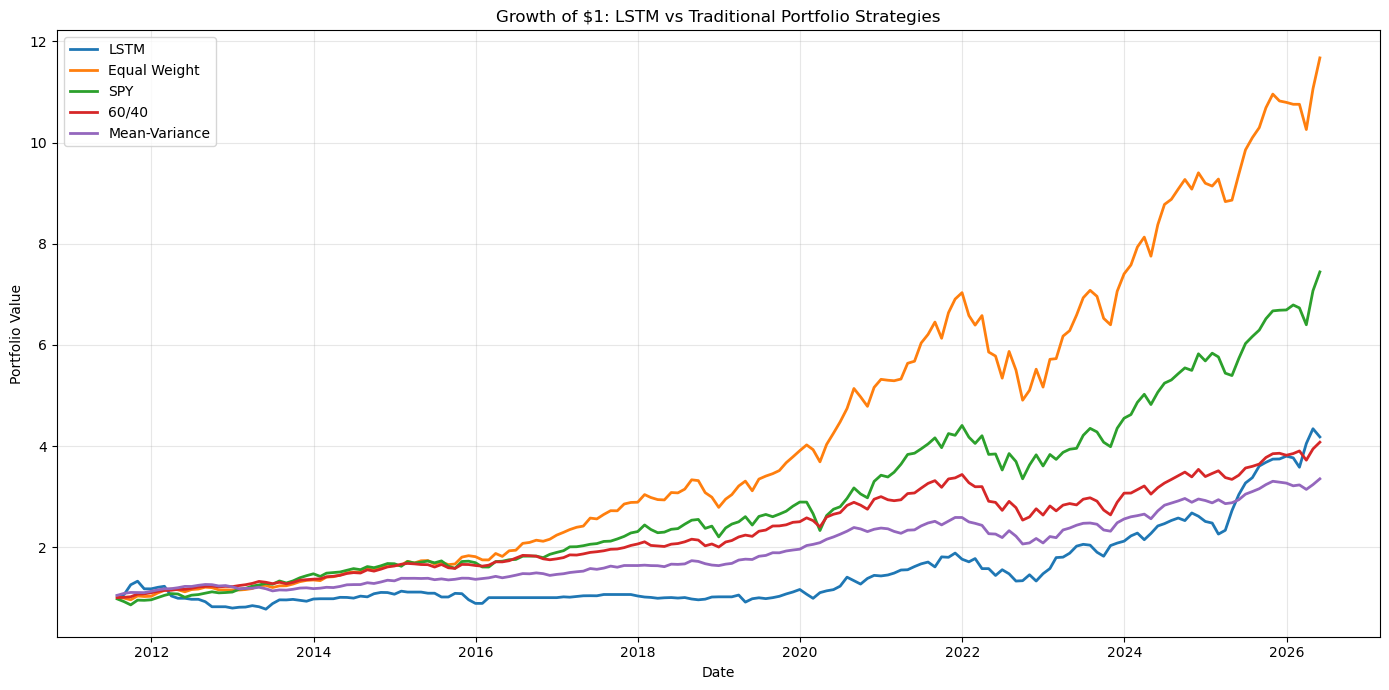

All final results were saved in:
lstm_final_results

Saved files:
- classification_metrics.csv
- confusion_matrix.csv
- growth_of_1_all_strategies.png
- lstm_minus_equal_weight.csv
- lstm_portfolio_returns.csv
- lstm_predictions.csv
- lstm_vs_all_benchmarks.csv
- mean_variance_results_and_weights.csv
- model_summary.csv
- performance_comparison.csv
- strategy_monthly_returns.csv


In [19]:
# ============================================================
# STAGE 15 UPDATED:
# GROWTH OF $1 AND SAVE ALL FINAL RESULTS
# ============================================================

RESULT_FOLDER = "lstm_final_results"

os.makedirs(
    RESULT_FOLDER,
    exist_ok=True
)

# ------------------------------------------------------------
# 1. Growth of $1 for all strategies
# ------------------------------------------------------------

wealth_comparison = (
    1 + comparison_returns
).cumprod()

plt.figure(figsize=(14, 7))

for strategy in wealth_comparison.columns:
    plt.plot(
        wealth_comparison.index,
        wealth_comparison[strategy],
        label=strategy,
        linewidth=2
    )

plt.title(
    "Growth of $1: LSTM vs Traditional Portfolio Strategies"
)
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{RESULT_FOLDER}/growth_of_1_all_strategies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 2. Save model predictions and portfolio results
# ------------------------------------------------------------

predictions_df.to_csv(
    f"{RESULT_FOLDER}/lstm_predictions.csv",
    index=False
)

lstm_portfolio.to_csv(
    f"{RESULT_FOLDER}/lstm_portfolio_returns.csv"
)

comparison_returns.to_csv(
    f"{RESULT_FOLDER}/strategy_monthly_returns.csv"
)

performance_table.to_csv(
    f"{RESULT_FOLDER}/performance_comparison.csv"
)

# ------------------------------------------------------------
# 3. Save Mean-Variance results and weights
# ------------------------------------------------------------

mvo_results.to_csv(
    f"{RESULT_FOLDER}/mean_variance_results_and_weights.csv"
)

# ------------------------------------------------------------
# 4. Save LSTM minus Equal Weight
# ------------------------------------------------------------

excess_return.to_csv(
    f"{RESULT_FOLDER}/lstm_minus_equal_weight.csv",
    header=["excess_return"]
)

# ------------------------------------------------------------
# 5. Save LSTM comparisons against all benchmarks
# ------------------------------------------------------------

lstm_vs_benchmarks.to_csv(
    f"{RESULT_FOLDER}/lstm_vs_all_benchmarks.csv"
)

# ------------------------------------------------------------
# 6. Save classification results
# ------------------------------------------------------------

classification_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

classification_summary.to_csv(
    f"{RESULT_FOLDER}/classification_metrics.csv",
    index=False
)

# ------------------------------------------------------------
# 7. Save confusion matrix
# ------------------------------------------------------------

confusion_matrix_df = pd.DataFrame(
    cm,
    index=[
        "Actual Negative",
        "Actual Positive"
    ],
    columns=[
        "Predicted Negative",
        "Predicted Positive"
    ]
)

confusion_matrix_df.to_csv(
    f"{RESULT_FOLDER}/confusion_matrix.csv"
)

print("All final results were saved in:")
print(RESULT_FOLDER)

print("\nSaved files:")

for filename in sorted(
    os.listdir(RESULT_FOLDER)
):
    print("-", filename)

In [21]:
# ============================================================
# CLASSIFICATION RESULTS BY ASSET
# Asset-Specific LSTM
# ============================================================

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. CHỌN DATAFRAME CHỨA KẾT QUẢ DỰ ĐOÁN
# ------------------------------------------------------------

# Đổi tên biến này nếu notebook của bạn dùng tên khác
classification_data = predictions_df.copy()

print("Available columns:")
print(classification_data.columns.tolist())

Available columns:
['asset', 'signal_date', 'probability', 'prediction', 'actual_direction', 'actual_return', 'seed']


In [23]:
# ============================================================
# CLASSIFICATION RESULTS BY ASSET
# ASSET-SPECIFIC LSTM
# ============================================================

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

classification_data = predictions_df.copy()

asset_classification_rows = []

for asset, asset_data in classification_data.groupby("asset"):

    y_true = asset_data["actual_direction"].astype(int)
    y_pred = asset_data["prediction"].astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    asset_classification_rows.append({
        "Asset": asset,
        "Observations": len(asset_data),

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "Positive Precision":
            precision_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),

        "Positive Recall":
            recall_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),

        "Negative Recall":
            recall_score(
                y_true,
                y_pred,
                pos_label=0,
                zero_division=0
            ),

        "Positive F1":
            f1_score(
                y_true,
                y_pred,
                pos_label=1,
                zero_division=0
            ),

        "Actual Positive Rate":
            y_true.mean(),

        "Predicted Positive Rate":
            y_pred.mean(),

        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })


asset_classification_table = pd.DataFrame(
    asset_classification_rows
).sort_values(
    "Balanced Accuracy",
    ascending=False
).reset_index(drop=True)

print("Asset-Specific LSTM Classification Results")

display(
    asset_classification_table.style.format({
        "Accuracy": "{:.2%}",
        "Balanced Accuracy": "{:.2%}",
        "Positive Precision": "{:.2%}",
        "Positive Recall": "{:.2%}",
        "Negative Recall": "{:.2%}",
        "Positive F1": "{:.2%}",
        "Actual Positive Rate": "{:.2%}",
        "Predicted Positive Rate": "{:.2%}"
    })
)

Asset-Specific LSTM Classification Results


,Asset,Observations,Accuracy,Balanced Accuracy,Positive Precision,Positive Recall,Negative Recall,Positive F1,Actual Positive Rate,Predicted Positive Rate,TN,FP,FN,TP
0,IEF,179,51.96%,53.47%,61.11%,23.40%,83.53%,33.85%,52.51%,20.11%,71,14,72,22
1,VNQ,179,43.02%,52.05%,75.00%,8.33%,95.77%,15.00%,60.34%,6.70%,68,3,99,9
2,TLT,179,50.28%,50.45%,51.43%,20.00%,80.90%,28.80%,50.28%,19.55%,72,17,72,18
3,QQQ,179,43.58%,50.08%,63.83%,26.32%,73.85%,37.27%,63.69%,26.26%,48,17,84,30
4,EFA,179,37.99%,49.43%,50.00%,1.80%,97.06%,3.48%,62.01%,2.23%,66,2,109,2
5,AAPL,179,44.13%,48.99%,56.41%,20.95%,77.03%,30.56%,58.66%,21.79%,57,17,83,22
6,MSFT,179,40.78%,48.04%,56.25%,16.36%,79.71%,25.35%,61.45%,17.88%,55,14,92,18
7,NVDA,179,39.11%,46.72%,57.50%,20.00%,73.44%,29.68%,64.25%,22.35%,47,17,92,23
8,SPY,179,41.34%,41.98%,61.73%,40.32%,43.64%,48.78%,69.27%,45.25%,24,31,74,50


In [24]:
report_classification_table = asset_classification_table[[
    "Asset",
    "Observations",
    "Accuracy",
    "Balanced Accuracy",
    "Positive Recall",
    "Negative Recall",
    "Actual Positive Rate",
    "Predicted Positive Rate"
]]

display(
    report_classification_table.style.format({
        "Accuracy": "{:.2%}",
        "Balanced Accuracy": "{:.2%}",
        "Positive Recall": "{:.2%}",
        "Negative Recall": "{:.2%}",
        "Actual Positive Rate": "{:.2%}",
        "Predicted Positive Rate": "{:.2%}"
    })
)

,Asset,Observations,Accuracy,Balanced Accuracy,Positive Recall,Negative Recall,Actual Positive Rate,Predicted Positive Rate
0,IEF,179,51.96%,53.47%,23.40%,83.53%,52.51%,20.11%
1,VNQ,179,43.02%,52.05%,8.33%,95.77%,60.34%,6.70%
2,TLT,179,50.28%,50.45%,20.00%,80.90%,50.28%,19.55%
3,QQQ,179,43.58%,50.08%,26.32%,73.85%,63.69%,26.26%
4,EFA,179,37.99%,49.43%,1.80%,97.06%,62.01%,2.23%
5,AAPL,179,44.13%,48.99%,20.95%,77.03%,58.66%,21.79%
6,MSFT,179,40.78%,48.04%,16.36%,79.71%,61.45%,17.88%
7,NVDA,179,39.11%,46.72%,20.00%,73.44%,64.25%,22.35%
8,SPY,179,41.34%,41.98%,40.32%,43.64%,69.27%,45.25%


In [25]:
asset_classification_table.to_csv(
    f"{RESULT_FOLDER}/classification_results_by_asset.csv",
    index=False
)

print(
    "Saved:",
    f"{RESULT_FOLDER}/classification_results_by_asset.csv"
)

Saved: lstm_final_results/classification_results_by_asset.csv
